# Plot CDF from PKL files

This notebook loads CDF PKL files and plots object/random curves per tracer.


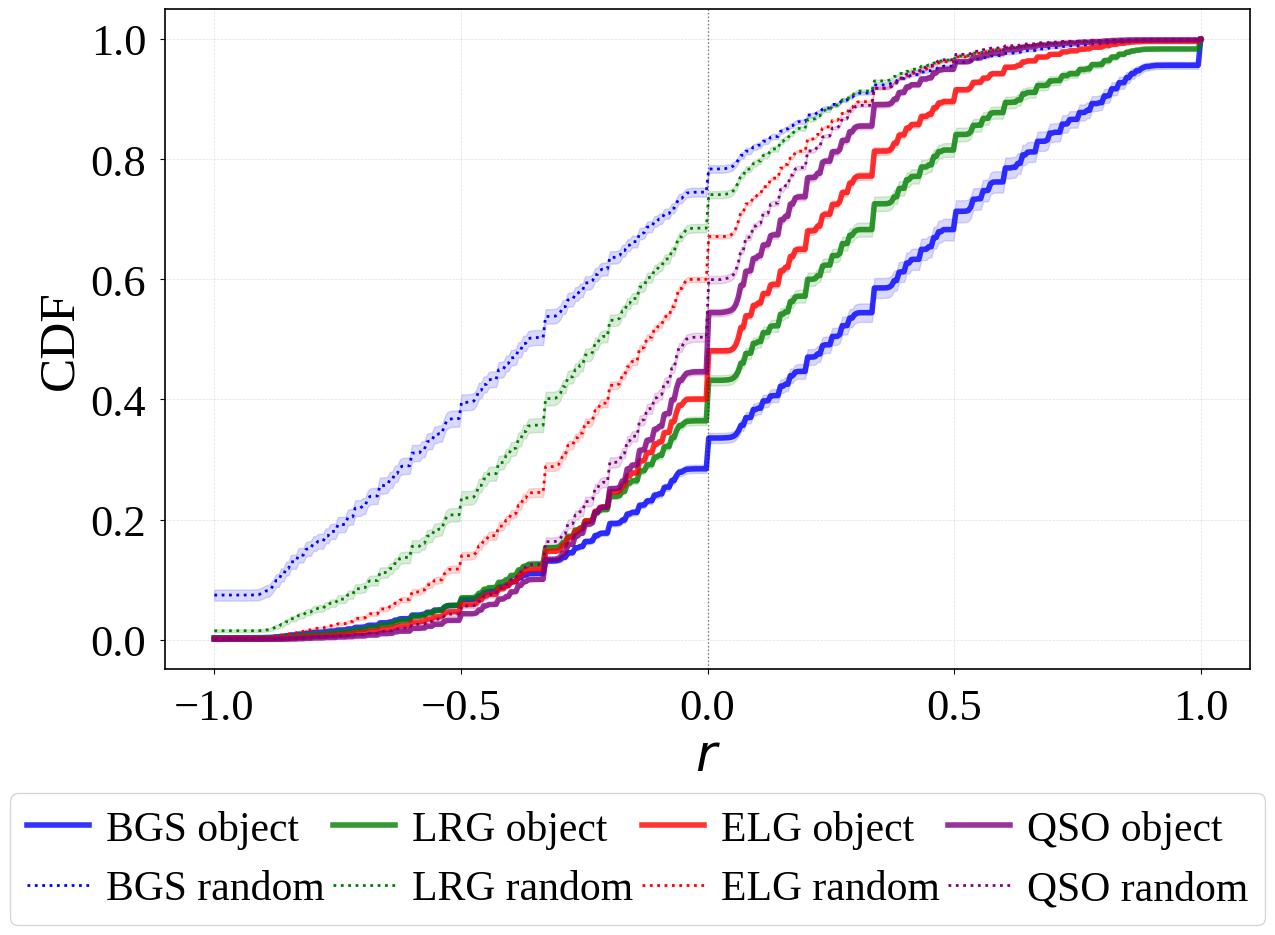

Figura guardada en /Users/soguevaram/Desktop/Research/DESI/plots/cdf_dispersion_zones.png


In [6]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Liberation Serif'
plt.rcParams['axes.linewidth'] = 1.2


def load_cdf_pkls(out_dir, tracers=None):
    if tracers is None:
        tracers = ['BGS_ANY', 'LRG', 'ELG', 'QSO']

    cdf_data = {}
    cdf_rand = {}

    for tr in tracers:
        data_path = os.path.join(out_dir, f"{tr}_cdf_data.pkl")
        rand_path = os.path.join(out_dir, f"{tr}_cdf_rand.pkl")

        cdf_data[tr] = None
        cdf_rand[tr] = None

        if os.path.exists(data_path):
            with open(data_path, 'rb') as f:
                cdf_data[tr] = pickle.load(f)

        if os.path.exists(rand_path):
            with open(rand_path, 'rb') as f:
                cdf_rand[tr] = pickle.load(f)

    return cdf_data, cdf_rand



def _extract_cdf(payload):
    if payload is None:
        return None

    if 'XGRID' in payload and 'MEAN' in payload:
        x = np.asarray(payload['XGRID'])
        mean = np.asarray(payload['MEAN'])
        std = np.asarray(payload['STD']) if 'STD' in payload else None
        return {'x': x, 'mean': mean, 'std': std}

    if 'r_sorted' in payload and 'cdf' in payload:
        return {
            'x': np.asarray(payload['r_sorted']),
            'mean': np.asarray(payload['cdf']),
            'std': None,
        }

    if 'MEAND' in payload:
        mean = np.asarray(payload['MEAND'])
        std = np.asarray(payload['STD']) if 'STD' in payload else None
        x = np.linspace(-1, 1, len(mean))
        return {'x': x, 'mean': mean, 'std': std}

    return None



def plot_cdf_from_pkl(out_dir, tracers=None):
    if tracers is None:
        tracers = ['BGS_ANY', 'LRG', 'ELG', 'QSO']

    tracer_color_map = {'BGS_ANY': 'blue', 'LRG': 'green', 'ELG': 'red', 'QSO': 'purple'}
    tracer_label_map = {'BGS_ANY': 'BGS', 'LRG': 'LRG', 'ELG': 'ELG', 'QSO': 'QSO'}

    cdf_data, cdf_rand = load_cdf_pkls(out_dir, tracers=tracers)

    fig, ax = plt.subplots(figsize=(14, 10))
    ax.grid(linewidth=0.5, alpha=0.4, linestyle='--')

    for tr in tracers:
        color = tracer_color_map.get(tr, 'black')
        label = tracer_label_map.get(tr, tr)

        payload_d = _extract_cdf(cdf_data.get(tr))
        if payload_d is not None:
            if payload_d['std'] is not None:
                ax.fill_between(payload_d['x'], payload_d['mean'] - payload_d['std'], payload_d['mean'] + payload_d['std'], alpha=0.15, color=color)
            ax.plot(payload_d['x'], payload_d['mean'], linewidth=4, color=color, label=f'{label} object',alpha=0.8)

        payload_r = _extract_cdf(cdf_rand.get(tr))
        if payload_r is not None:
            if payload_r['std'] is not None:
                ax.fill_between(payload_r['x'], payload_r['mean'] - payload_r['std'], payload_r['mean'] + payload_r['std'], alpha=0.15, color=color)
            ax.plot(payload_r['x'], payload_r['mean'], linewidth=2, linestyle=':', color=color, label=f'{label} random')

    ax.axvline(x=0, color='black', linestyle=':', linewidth=1, alpha=0.5)
    ax.set_ylabel('CDF', fontsize=37,labelpad=5)
    ax.set_xlabel(r"$r$", fontsize=37,labelpad=5)
    ax.tick_params(axis="both", labelsize=32,pad = 10)
    fig.subplots_adjust(bottom=0.22)

    bb = ax.get_position()
    fig.legend(
        *ax.get_legend_handles_labels(),
        loc="upper left",
        ncol=4,
        frameon=True,
        fontsize=30,
        bbox_to_anchor=(bb.x0-0.2, bb.y0 , bb.width, 0.001),
        bbox_transform=fig.transFigure,
        borderaxespad=3,
        columnspacing=0.2,
        handlelength=1.5,
        handletextpad=0.4
    )

    os.makedirs(os.path.join(out_dir, "cdf"), exist_ok=True)
    path = '/Users/soguevaram/Desktop/Research/DESI/plots/cdf_dispersion_zones.png'
    plt.show()
    fig.savefig(path, dpi=360, bbox_inches='tight')
    print(f"Figura guardada en {path}")


base_dir = '/Users/soguevaram/Desktop/Research/DESI/data'
out_dir = os.path.join(base_dir, 'results/cdf')

plot_cdf_from_pkl(out_dir=out_dir)
